# Zero-shot integration tutorial with scGPT

## Introduction

This tutorial covers the zero-shot integration with scGPT. This particular workflow works for scRNA-seq datasets without fine-tuning (or any extensive training) of scGPT.


This code branches off from a provided tutorial by the authors of the scGPT paper. The original can be found here: https://github.com/bowang-lab/scGPT/blob/main/tutorials/zero-shot/Tutorial_ZeroShot_Integration.ipynb.

We will use the Lung-Kim dataset as an example. The dataset comprises 14 primary human lung adenocarcinoma samples and 32,493 cells. This dataset is publicly accessible via the [Curated Cancer Cell Atlas](https://www.weizmann.ac.il/sites/3CA/lung), which can be downloaded from [here](https://drive.google.com/file/d/1z_0vWYMhRuRiD1EyhuFtY9ReIR0msWaL/view?usp=sharing). You may place the dataset under `data` directory at the outer level.

For scGPT model weight, we use the `scGPT_human` model to provide embeddings out of the box. You may download it from [here](https://drive.google.com/drive/folders/1oWh_-ZRdhtoGQ2Fw24HP41FgLoomVo-y).


The zero-shot integration workflow is as follows:

 1. [Load and pre-process the dataset](#prepare-the-datasets)
    
 2. [Generate scGPT embeddings for each cell](#generate-the-cell-embeddings)

At the [appendix](#appendix-zero-shot-integration-on-covid-19-dataset-and-ms-dataset) of this tutorial notebook, we will also showcase the zero-shot integration performance on COVID-19 dataset and Multiple Sclerosis (M.S.) dataset, you can find and download the datasets here: [COVID-19](https://drive.google.com/file/d/1eD9LbxNJ35YUde3VtdVcjkwm-f4iyJ6x/view?usp=drive_link) and [MS](https://drive.google.com/drive/folders/1Qd42YNabzyr2pWt9xoY4cVMTAxsNBt4v?usp=sharing)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bowang-lab/scGPT/blob/main/tutorials/zero-shot/Tutorial_ZeroShot_Integration.ipynb)

In [ ]:
# Specifically for Google Colab, install dependencies and download data

import os
import sys
%load_ext autoreload
%autoreload 2

if "google.colab" in sys.modules:
    print("Running on Google Colab")
    print("Installing dependencies...")
    !pip install -U scgpt "torch<=2.2.2" "numpy==1.23.5" "umap-learn<0.5.7"
    # the optional dependency of flash-attion is skipped on colab
    !pip install wandb louvain

    # NOTE: MAY NEED TO RESTART RUNTIME AFTER THE INSTALLATION

    print("Downloading data and model ckpt...")
    !pip install -q -U gdown
    import gdown

    data_dir = "../../data"
    if not os.path.exists(data_dir):
        os.mkdir(data_dir)
    if not os.path.exists(os.path.join(data_dir, "Kim2020_Lung.h5ad")):
        !gdown https://drive.google.com/uc?id=1z_0vWYMhRuRiD1EyhuFtY9ReIR0msWaL -O $data_dir/
    if not os.path.exists(os.path.join(data_dir, "covid_subsampled.h5ad")):
        !gdown https://drive.google.com/uc?id=1eD9LbxNJ35YUde3VtdVcjkwm-f4iyJ6x -O $data_dir/
    if not os.path.exists(os.path.join(data_dir, "ms")):
        gdown.download_folder(
            "https://drive.google.com/drive/folders/1Qd42YNabzyr2pWt9xoY4cVMTAxsNBt4v",
            output=os.path.join(data_dir, "ms"),
        )

    print("Downloading model ckpt...")
    model_dir = "../../save/scGPT_human"
    if not os.path.exists(model_dir):
        !mkdir -p $model_dir
        gdown.download_folder(
            "https://drive.google.com/drive/folders/1oWh_-ZRdhtoGQ2Fw24HP41FgLoomVo-y",
            output=model_dir,
        )



## Import scGPT and dependencies

In [ ]:
from pathlib import Path
import warnings

import scanpy as sc
import scib
import numpy as np
import sys

sys.path.insert(0, "../")

import scgpt as scg
import matplotlib.pyplot as plt
import anndata

plt.style.context('default')
warnings.simplefilter("ignore", ResourceWarning)

model_dir = Path("../../save/scGPT_human")

## Prepare the datasets

MS dataset

In [ ]:
gdown.download_folder(
            "https://drive.google.com/drive/folders/1Qd42YNabzyr2pWt9xoY4cVMTAxsNBt4v",
            output=os.path.join(data_dir, "ms"),
        )

In [ ]:


gene_col = "gene_name"
cell_type_key = "celltype"
batch_key = "Sample Characteristic[individual]"

train_data = sc.read_h5ad('../../data/ms/c_data.h5ad')
test_data = sc.read_h5ad('../../data/ms/filtered_ms_adata.h5ad')
test_data.var.index = test_data.var[gene_col]
adata = anndata.concat([train_data, test_data], join='outer')
# print(adata)
adata.var[gene_col] = adata.var.index

print(adata.obs[cell_type_key])

SRR9123032-AACACGTAGCGTAATA      cortical layer 5-6 excitatory neuron
SRR9123032-AACCATGAGAAACGAG              PVALB-expressing interneuron
SRR9123032-AACCGCGAGGCCATAG    cortical layer 2-3 excitatory neuron B
SRR9123032-AACTCCCGTGTGACCC                         oligodendrocyte C
SRR9123032-AACTTTCCAGCTCGAC                VIP-expressing interneuron
                                                ...                  
SRR9123052-TTTGGTTCATCCGGGT      cortical layer 5-6 excitatory neuron
SRR9123052-TTTGGTTCATCGATGT      cortical layer 5-6 excitatory neuron
SRR9123052-TTTGGTTGTCAACTGT                VIP-expressing interneuron
SRR9123052-TTTGTCAAGGCTACGA      cortical layer 5-6 excitatory neuron
SRR9123052-TTTGTCAGTTAGGGTG    cortical layer 2-3 excitatory neuron B
Name: celltype, Length: 21312, dtype: category
Categories (18, object): ['PVALB-expressing interneuron', 'SST-expressing interneuron',
                          'SV2C-expressing interneuron', 'VIP-expressing interneuron', ..., 'ol

In [ ]:
embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)
print(embed_adata.obs[cell_type_key])

In [ ]:
print(embed_adata.obsm["X_scGPT"].shape)


fn = 'ms_embedded.npy'

np.save(fn, embed_adata.obsm["X_scGPT"])

fn = 'ms_targets.csv'
embed_adata.obs[cell_type_key].to_csv(fn)

(21312, 512)


<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()


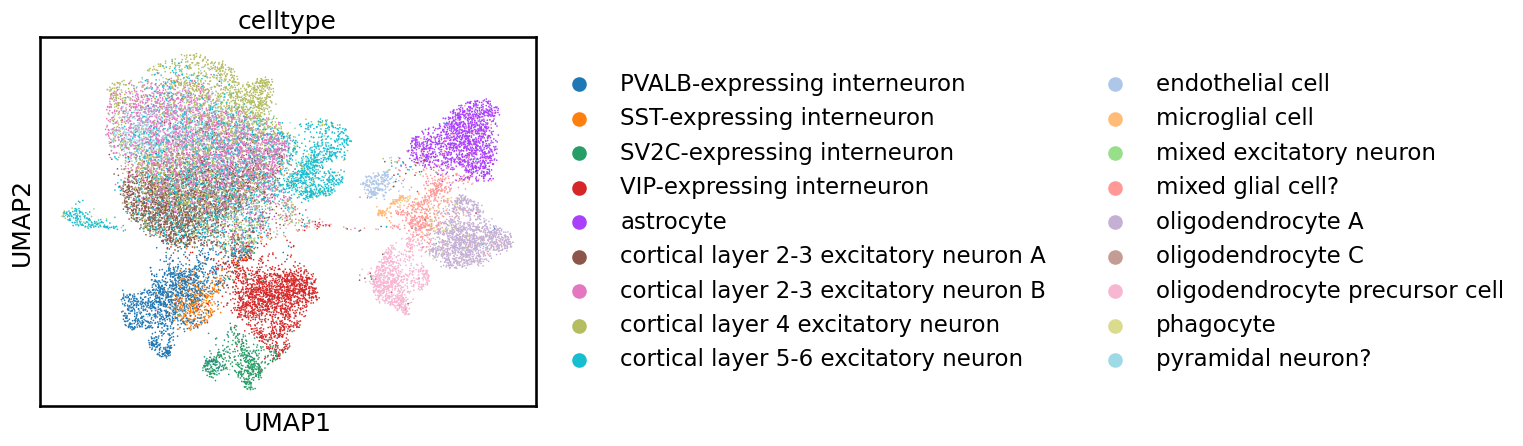

In [ ]:
sc.pp.neighbors(embed_adata, use_rep="X_scGPT")
sc.tl.umap(embed_adata)
sc.pl.umap(embed_adata,
           color=[cell_type_key],
           frameon=True,
           title=["celltype"])

## pmbc 10k dataset:


In [3]:
fn = 'adata_pmbc_10k.h5ad'
adata = sc.read_h5ad(fn)  # 11990 × 3346

# print(adata)

gene_col = "gene_name"
cell_type_key = "celltype"

ori_batch_col = "batch"
adata.obs[cell_type_key] = adata.obs["str_labels"].astype("category")

adata.var = adata.var.set_index("gene_symbols")
data_is_raw = True

# make the batch category column
adata.obs["str_batch"] = adata.obs[ori_batch_col].astype(str)
batch_id_labels = adata.obs["str_batch"].astype("category").cat.codes.values
adata.obs["batch_id"] = batch_id_labels
adata.var[gene_col] = adata.var.index.tolist()
print(adata.obs[cell_type_key])

AAACCTGAGCTAGTGG-1        CD4 T cells
AAACCTGCACATTAGC-1        CD4 T cells
AAACCTGCACTGTTAG-1    CD14+ Monocytes
AAACCTGCATAGTAAG-1    CD14+ Monocytes
AAACCTGCATGAACCT-1        CD8 T cells
                           ...       
TTTGGTTTCGCTAGCG-1    CD14+ Monocytes
TTTGTCACACTTAACG-1        CD8 T cells
TTTGTCACAGGTCCAC-1           NK cells
TTTGTCAGTTAAGACA-1            B cells
TTTGTCATCCCAAGAT-1    CD14+ Monocytes
Name: celltype, Length: 11990, dtype: category
Categories (9, object): ['B cells', 'CD4 T cells', 'CD8 T cells', 'CD14+ Monocytes', ...,
                         'FCGR3A+ Monocytes', 'Megakaryocytes', 'NK cells', 'Other']


In [ ]:
embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

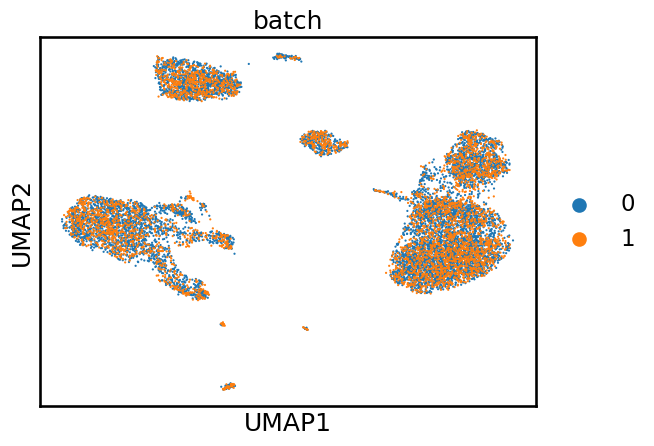

In [7]:
sc.pp.neighbors(embed_adata, use_rep="X_scGPT")
sc.tl.umap(embed_adata, min_dist=0.3)
fig = sc.pl.umap(
    embed_adata,
    color=["str_batch"],
    title=[f"batch"],
    frameon=True,
    return_fig=True,
    show=True,
)

In [ ]:
print(embed_adata)
fn = 'embedded_pmbc_10k.h5ad'
embed_adata.write_h5ad(fn)

AnnData object with n_obs × n_vars = 11990 × 3256
    obs: 'n_counts', 'batch', 'labels', 'str_labels', 'celltype', 'str_batch', 'batch_id'
    var: 'n_counts-0', 'n_counts-1', 'n_counts', 'gene_name', 'id_in_vocab'
    uns: 'cell_types'
    obsm: 'design', 'normalized_qc', 'qc_pc', 'raw_qc', 'X_scGPT'


## MOUSE


In [ ]:
adata = anndata.io.read_csv('mouse_brain_processed_RNA.csv')
# print(adata)
# adata.obs_names_make_unique()
# adata.var = adata.var.set_index("gene_names")
gene_col = "gene_name"
cell_type_key = "celltype"
adata.var.index.name = "gene_name"
# print(adata.var.index )
# adata.var.index  = o[:865]
# print(o[:865])
adata.var.index = adata.var.index.str.upper()
adata.var[gene_col] = adata.var.index  #o[:865]
print(adata.var[gene_col])



# print(adata.var[gene_col])

#[adata.var.index[i] for i in range(adata.n_vars)]
adata.obs[cell_type_key] =  adata.obs.index.astype("category") #[adata.var.index[i] for i in range(adata.n_vars)]

# Simulate batch info (as strings) for the 100 cells
# batches = np.random.choice([0, 1], size=adata.n_obs)
# batches = np.zeros(adata.n_obs)
# Add this as a new column in adata.obs
# adata.obs['str_batch'] = batches
from scgpt.tokenizer.gene_tokenizer import GeneVocab
model_config_file = model_dir / "args.json"
model_file = model_dir / "best_model.pt"
vocab_file = model_dir / "vocab.json"

vocab = GeneVocab.from_file(vocab_file)
# model_dir = Path("../../save/scGPT_human")
adata.var["id_in_vocab"] = [
        1 if gene in vocab else -1 for gene in adata.var["gene_name"]
    ]

gene_name
2600014E21RIK    2600014E21RIK
2810403D21RIK    2810403D21RIK
3110099E03RIK    3110099E03RIK
4632427E13RIK    4632427E13RIK
6030442K20RIK    6030442K20RIK
                     ...      
ZIC1                      ZIC1
ZIC2                      ZIC2
ZIC4                      ZIC4
ZIC5                      ZIC5
ZWILCH                  ZWILCH
Name: gene_name, Length: 865, dtype: object


/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:

embed_adata = scg.tasks.embed_data(
    adata,
    model_dir,
    gene_col=gene_col,
    batch_size=64,
)

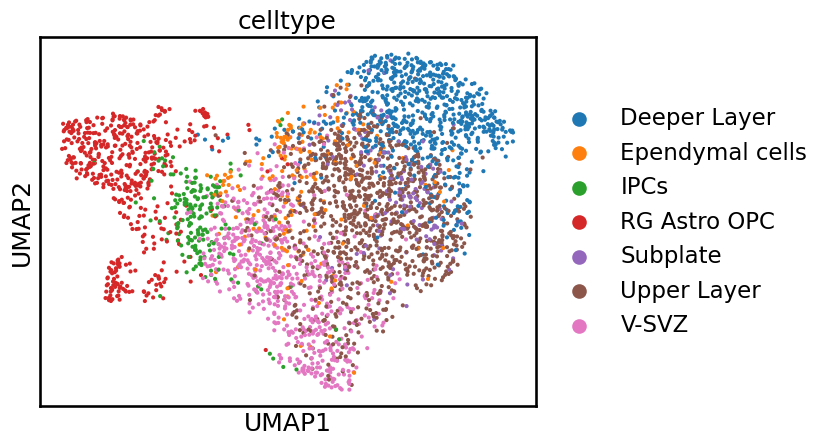

In [ ]:
sc.pp.neighbors(embed_adata, use_rep="X_scGPT")
sc.tl.umap(embed_adata)
sc.pl.umap(embed_adata,
           color=[cell_type_key],
           frameon=True,
           title=["celltype"])

In [ ]:

print(embed_adata.obs[cell_type_key].shape)
# print(embed_adata.var.shape)


fn = 'mouse_embedded.npy'
# embed_adata.obsm["X_scGPT"].write_h5ad(fn)

np.save(fn, embed_adata.obsm["X_scGPT"])

fn = 'mouse_targets.csv'
embed_adata.obs[cell_type_key].to_csv(fn)

(3365,)


<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
